# Module 8: Grad Café Data Cleaning and Exploratory Analysis

This notebook loads Grad Café applicant data from Amazon S3 into an Amazon SageMaker environment. The dataset is cleaned and validated using Pandas and NumPy, analyzed using SciPy, and visualized using Matplotlib. The final cleaned dataset is exported and uploaded back to Amazon S3 for downstream use.

In [1]:
from pathlib import Path
import json
import os
import re

import boto3
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

## 1. Load Raw Grad Café Data from S3

This section downloads the raw Grad Café dataset from Amazon S3 and converts the JSONL file into a standard JSON format. The dataset is then loaded into a Pandas DataFrame for further analysis.

In [2]:
def download_from_s3(*, bucket: str, key: str, dest_path: str) -> Path:
    """Download an object from S3 to a local file path."""
    s3 = boto3.client("s3")
    destination = Path(dest_path)
    destination.parent.mkdir(parents=True, exist_ok=True)
    s3.download_file(bucket, key, str(destination))
    return destination


def jsonl_to_json(*, jsonl_path: str, json_path: str) -> Path:
    """Convert JSONL (one JSON object per line) into one JSON list file."""
    src = Path(jsonl_path)
    out = Path(json_path)
    out.parent.mkdir(parents=True, exist_ok=True)

    records = []
    with src.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))

    with out.open("w", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False, indent=2)

    return out

### Download the raw dataset from Amazon S3

The following code downloads the raw Grad Café JSONL dataset from Amazon S3 and converts it into a standard JSON file for loading into Pandas.

In [3]:
BUCKET = "grad-cafe-ic"
S3_KEY = "llm_extend_applicant_data.jsonl"

local_jsonl = download_from_s3(
    bucket=BUCKET,
    key=S3_KEY,
    dest_path="llm_extend_applicant_data_SM.jsonl",
)

local_json = jsonl_to_json(
    jsonl_path=str(local_jsonl),
    json_path="applicant_data_SM.json",
)

print("Downloaded:", local_jsonl)
print("Created JSON:", local_json)
print("Exists?", Path(local_json).exists())

Downloaded: llm_extend_applicant_data_SM.jsonl
Created JSON: applicant_data_SM.json
Exists? True


## 2. Inspect the Raw Dataset

This section loads the converted JSON file into a Pandas DataFrame, preserves a raw copy of the original dataset, and inspects the structure of the data before cleaning.

In [4]:
df = pd.read_json(local_json)
raw_df = df.copy()

print("Data loaded successfully.")
print("Shape:", df.shape)

Data loaded successfully.
Shape: (30000, 17)


### Display the first five rows of the raw dataset

The table below shows the first five rows of the raw dataset before any cleaning is performed.

In [5]:
df.head()

,program_name,university,comments,date_added,entry_url,applicant_status,acceptance_date,rejection_date,start_term,international_american,gre_score,gre_v_score,gre_aw,degree,gpa,llm-generated-program,llm-generated-university
0,Biomedical Engineering,Tufts University,None,"January 30, 2026",https://www.thegradcafe.com/result/993593,Rejected,None,29 Jan,Fall 2026,International,NaN,NaN,NaN,PhD,NaN,Biomedical Engineering,Tufts University
1,Sociocultural Anthropology,Stanford University,Graduate GPA,"January 30, 2026",https://www.thegradcafe.com/result/993592,Rejected,None,28 Jan,Fall 2026,American,NaN,NaN,NaN,PhD,3.85,Sociocultuural Anthropology,Stanford University
2,Public Administration,University of Kansas,None,"January 30, 2026",https://www.thegradcafe.com/result/993591,Rejected,None,20 Jan,Fall 2026,International,NaN,NaN,NaN,PhD,NaN,Public Administration,University of Kansas
3,"Health Promotion, Education, and Behavior",University of South Carolina,None,"January 30, 2026",https://www.thegradcafe.com/result/993590,Rejected,None,30 Jan,Fall 2026,International,NaN,NaN,NaN,PhD,NaN,"Health Promotion, Education, And Behavior",University of South Carolina
4,Clinical Psychology,University of California (UCLA),None,"January 30, 2026",https://www.thegradcafe.com/result/993589,Accepted,30 Jan,None,Fall 2026,American,NaN,NaN,NaN,PhD,4.00,Clinical Psychology,"University of California, Los Angeles"


## 2. Inspect the Raw Dataset

The raw Grad Café JSON dataset is loaded into a Pandas DataFrame.  
A copy of the raw dataset is preserved as `raw_df` before any cleaning steps are applied.

In [6]:
df = pd.read_json(local_json)

# Preserve original dataset before cleaning
raw_df = df.copy()

print("Data loaded successfully.")
print("Shape:", df.shape)

Data loaded successfully.
Shape: (30000, 17)


### Report dataset structure

The following code reports the number of rows, number of columns, column names, and data types of each column in the raw dataset.

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDatatype of each column:")
print(df.dtypes)

Number of rows: 30000
Number of columns: 17

Column names:
['program_name', 'university', 'comments', 'date_added', 'entry_url', 'applicant_status', 'acceptance_date', 'rejection_date', 'start_term', 'international_american', 'gre_score', 'gre_v_score', 'gre_aw', 'degree', 'gpa', 'llm-generated-program', 'llm-generated-university']

Datatype of each column:
program_name                 object
university                   object
comments                     object
date_added                   object
entry_url                    object
applicant_status             object
acceptance_date              object
rejection_date               object
start_term                   object
international_american       object
gre_score                   float64
gre_v_score                 float64
gre_aw                      float64
degree                       object
gpa                         float64
llm-generated-program        object
llm-generated-university     object
dtype: object


## Missingness Summary

This section computes the number and percentage of missing values in each column of the raw dataset.

In [8]:
missing_count = df.isna().sum()

missing_percent = (missing_count / len(df)) * 100

missingness_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
}).sort_values(by="missing_percent", ascending=False)

missingness_summary

,missing_count,missing_percent
gre_aw,28215,94.050000
gre_v_score,28107,93.690000
gre_score,27747,92.490000
acceptance_date,19848,66.160000
rejection_date,17958,59.860000
comments,15494,51.646667
gpa,12872,42.906667
degree,1318,4.393333
international_american,31,0.103333
program_name,24,0.080000


In [9]:
missingness_summary.to_csv("missingness_summary.csv")
print("Saved: missingness_summary.csv")

Saved: missingness_summary.csv


## 3. Clean and Standardize the Dataset

This section removes invalid rows, standardizes fields, parses dates, validates categorical values, and converts numeric columns into usable formats for analysis.

### Remove rows where the program field is missing

Rows where `program` is missing are removed from the working DataFrame. The original raw dataset remains preserved in `raw_df`.

In [10]:
raw_row_count = len(df)

df = df[df["program_name"].notna()].copy()

after_program_filter_count = len(df)
removed_program_none = raw_row_count - after_program_filter_count

print("Rows removed where program_name is None:", removed_program_none)
print("Current shape:", df.shape)

Rows removed where program_name is None: 24
Current shape: (29976, 17)


### Clean text-based columns
Leading and trailing whitespace is removed and repeated spaces are collapsed.

In [11]:
text_cols = [
    "program_name",
    "university",
    "applicant_status",
    "degree",
    "international_american",
    "start_term"
]

for col in text_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype("string")
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )

### Identify low-frequency programs
Programs appearing fewer than three times are displayed.

In [12]:
program_counts = df["program_name"].value_counts()

low_program_count = program_counts[program_counts < 3]

low_program_count

program_name
Health and Public Policy                            2
Microbiology and Molecular Genetics (MMG)           2
Near Eastern languages and Civilizations            2
Language, Literacy, and Social Studies Education    2
Integrative Genetics And Genomics                   2
                                                   ..
Applied AI                                          1
Communication and Advocacy                          1
Clinical rehabilitation counseling                  1
Environmental and Forest Sciences (SEFS)            1
Multidisciplinary Biomedical Sciences               1
Name: count, Length: 2028, dtype: Int64

### Convert date_added and infer decision_date from start_term

The `date_added` column is converted directly to datetime.  
Because `acceptance_date` and `rejection_date` contain only day and month values, the year is inferred from the `start_term` column to create a complete `decision_date`.

In [13]:
# Convert application date to datetime
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

# Extract year from start_term
df["term_year"] = (
    df["start_term"]
    .astype("string")
    .str.extract(r"(\d{4})", expand=False)
)

# Clean acceptance/rejection date text
df["acceptance_date"] = (
    df["acceptance_date"]
    .astype("string")
    .str.strip()
    .replace("None", pd.NA)
)

df["rejection_date"] = (
    df["rejection_date"]
    .astype("string")
    .str.strip()
    .replace("None", pd.NA)
)

# Create outcome column
df["outcome"] = np.select(
    [
        df["acceptance_date"].notna(),
        df["rejection_date"].notna(),
        df["applicant_status"].str.contains("wait", case=False, na=False),
        df["applicant_status"].str.contains("interview", case=False, na=False)
    ],
    [
        "Accepted",
        "Rejected",
        "Waitlisted",
        "Interviewed"
    ],
    default=None
)

# Build decision date text from acceptance/rejection columns
df["decision_date_text"] = np.where(
    df["acceptance_date"].notna(),
    df["acceptance_date"],
    np.where(
        df["rejection_date"].notna(),
        df["rejection_date"],
        pd.NA
    )
)

# Combine day/month text with inferred year from start_term
df["decision_date_full"] = np.where(
    pd.notna(df["decision_date_text"]) & pd.notna(df["term_year"]),
    df["decision_date_text"] + " " + df["term_year"],
    pd.NA
)

# Convert inferred decision date to real datetime
df["decision_date"] = pd.to_datetime(
    df["decision_date_full"],
    format="%d %b %Y",
    errors="coerce"
)

# Create a display version for the screenshot only
display_df = df[[
    "applicant_status",
    "date_added",
    "acceptance_date",
    "rejection_date",
    "start_term",
    "term_year",
    "outcome",
    "decision_date"
]].copy()

display_df["decision_date"] = display_df["decision_date"].dt.strftime("%d %b %Y")

display_df.head(10)

,applicant_status,date_added,acceptance_date,rejection_date,start_term,term_year,outcome,decision_date
0,Rejected,2026-01-30,<NA>,29 Jan,Fall 2026,2026,Rejected,29 Jan 2026
1,Rejected,2026-01-30,<NA>,28 Jan,Fall 2026,2026,Rejected,28 Jan 2026
2,Rejected,2026-01-30,<NA>,20 Jan,Fall 2026,2026,Rejected,20 Jan 2026
3,Rejected,2026-01-30,<NA>,30 Jan,Fall 2026,2026,Rejected,30 Jan 2026
4,Accepted,2026-01-30,30 Jan,<NA>,Fall 2026,2026,Accepted,30 Jan 2026
5,Rejected,2026-01-30,<NA>,15 Jan,Fall 2026,2026,Rejected,15 Jan 2026
6,Rejected,2026-01-30,<NA>,26 Jan,Fall 2026,2026,Rejected,26 Jan 2026
7,Rejected,2026-01-30,<NA>,29 Jan,Fall 2026,2026,Rejected,29 Jan 2026
8,Waitlisted,2026-01-30,<NA>,<NA>,Fall 2026,2026,Waitlisted,NaN
9,Rejected,2026-01-30,<NA>,29 Jan,Fall 2026,2026,Rejected,29 Jan 2026


### Standardize and validate degree values

The degree column may contain multiple text variants for the same degree type. Before validating the allowed values, the code below standardizes common variants so that equivalent entries are grouped together consistently.

Only the valid degree categories `Master's`, `PhD`, and `PsyD` are retained in the cleaned dataset.

In [14]:
# Standardize common degree variants
df["degree"] = df["degree"].replace({
    "Masters": "Master's",
    "Master": "Master's",
    "MS": "Master's",
    "M.S.": "Master's",
    "MSc": "Master's",
    "M.S": "Master's",
    "Ph.D": "PhD",
    "Ph.D.": "PhD",
    "Phd": "PhD"
})

# Keep only valid degree values
valid_degrees = ["Master's", "PhD", "PsyD"]

before_degree = len(df)
invalid_degree_count = (~df["degree"].isin(valid_degrees)).sum()

df = df[df["degree"].isin(valid_degrees)].copy()

print("Invalid Degree rows dropped:", invalid_degree_count)
print("Current shape:", df.shape)
print(df["degree"].value_counts(dropna=False))

Invalid Degree rows dropped: 1315
Current shape: (28661, 22)
degree
PhD         21662
Master's     6999
Name: count, dtype: Int64


### Validate US/International values

The residency column is standardized so that only `International`, `American`, or `Other` remain in the cleaned dataset.

In [15]:
df["international_american"] = df["international_american"].replace({
    "US": "American",
    "U.S.": "American",
    "USA": "American",
    "International Student": "International"
})

valid_usintl = ["International", "American", "Other"]
invalid_usintl_count = (~df["international_american"].isin(valid_usintl)).sum()

df = df[df["international_american"].isin(valid_usintl)].copy()

print("Invalid US/International rows dropped:", invalid_usintl_count)
print("Current shape:", df.shape)
print(df["international_american"].value_counts(dropna=False))

Invalid US/International rows dropped: 30
Current shape: (28631, 22)
international_american
International    14898
American         13733
Name: count, dtype: Int64


### Convert GPA and GRE-related columns to float

The GPA and GRE-related columns are converted into numeric float-based columns for analysis.

In [16]:
numeric_cols = ["gpa", "gre_score", "gre_v_score", "gre_aw"]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(float)

df[numeric_cols].head(10)

,gpa,gre_score,gre_v_score,gre_aw
0,NaN,NaN,NaN,NaN
1,3.85,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,4.00,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN
8,NaN,NaN,NaN,NaN
9,4.00,170.0,NaN,NaN


## 5. Data Validation Checks

This section reports the number of rows removed during cleaning, the final shape of the cleaned dataset, the counts of dropped entries by rule, and a comparison of the raw and cleaned row counts.

In [17]:
final_row_count = len(df)
total_rows_removed = len(raw_df) - len(df)

validation_summary = pd.DataFrame({
    "rule": [
        "Rows removed where program_name is None",
        "Invalid Degree rows dropped",
        "Invalid US/International rows dropped",
        "Total rows removed"
    ],
    "count": [
        removed_program_none,
        invalid_degree_count,
        invalid_usintl_count,
        total_rows_removed
    ]
})

print("Raw row count:", len(raw_df))
print("Cleaned row count:", len(df))
print("Final shape:", df.shape)

validation_summary

Raw row count: 30000
Cleaned row count: 28631
Final shape: (28631, 22)


,rule,count
0,Rows removed where program_name is None,24
1,Invalid Degree rows dropped,1315
2,Invalid US/International rows dropped,30
3,Total rows removed,1369


## 4. Feature Engineering

This section creates derived analytical columns using vectorized Pandas and NumPy operations.

### Derived Analytical Columns

Several new columns were created using vectorized Pandas and NumPy operations to support later statistical analysis.

**has_valid_gpa**
- Set to 1 if a GPA value exists and is between 0 and 4.0 (inclusive).
- Set to 0 otherwise.

**has_valid_gre**
- Set to 1 if a GRE score exists and is greater than 0.
- Set to 0 otherwise.

**has_valid_gre_v**
- Set to 1 if a GRE Verbal score exists and is greater than 0.
- Set to 0 otherwise.

In [18]:
df["has_valid_gpa"] = np.where(df["gpa"].between(0, 4.0, inclusive="both"), 1, 0)

df["has_valid_gre"] = np.where(
    df["gre_score"].notna() & (df["gre_score"] > 0),
    1,
    0
)

df["has_valid_gre_v"] = np.where(
    df["gre_v_score"].notna() & (df["gre_v_score"] > 0),
    1,
    0
)

### Derived Analytical Columns

Several new columns were created using vectorized Pandas and NumPy operations to support later statistical analysis.

**days_to_decision**
- Calculated as the difference (in days) between `decision_date` and `date_added`.
- Negative values were treated as missing because they likely reflect delays in data entry rather than true negative decision times.

**decision_speed**
- A categorical variable derived from `days_to_decision`:
  - `0–30 days`
  - `31–60 days`
  - `61+ days`
  - `Unknown` when no decision date is available.

**application_season**
- Derived from the month of `date_added`.
- Months were grouped into three categories:
  - `Early Cycle`
  - `Mid Cycle`
  - `Late Cycle`

In [19]:
df["days_to_decision"] = (df["decision_date"] - df["date_added"]).dt.days

# Remove negative decision times
df.loc[df["days_to_decision"] < 0, "days_to_decision"] = np.nan

In [20]:
decision_conditions = [
    df["days_to_decision"].between(0, 30, inclusive="both"),
    df["days_to_decision"].between(31, 60, inclusive="both"),
    df["days_to_decision"] > 60
]

decision_choices = [
    "0-30 days",
    "31-60 days",
    "61+ days"
]

df["decision_speed"] = np.select(
    decision_conditions,
    decision_choices,
    default="Unknown"
)

In [21]:
month = df["date_added"].dt.month

season_conditions = [
    month.isin([8, 9, 10, 11]),
    month.isin([12, 1, 2]),
    month.isin([3, 4, 5, 6, 7])
]

season_choices = [
    "Early Cycle",
    "Mid Cycle",
    "Late Cycle"
]

df["application_season"] = np.select(
    season_conditions,
    season_choices,
    default="Unknown"
)

df[[
    "gpa",
    "gre_score",
    "gre_v_score",
    "has_valid_gpa",
    "has_valid_gre",
    "has_valid_gre_v",
    "days_to_decision",
    "decision_speed",
    "application_season"
]].head()

,gpa,gre_score,gre_v_score,has_valid_gpa,has_valid_gre,has_valid_gre_v,days_to_decision,decision_speed,application_season
0,NaN,NaN,NaN,0,0,0,NaN,Unknown,Mid Cycle
1,3.85,NaN,NaN,1,0,0,NaN,Unknown,Mid Cycle
2,NaN,NaN,NaN,0,0,0,NaN,Unknown,Mid Cycle
3,NaN,NaN,NaN,0,0,0,0.0,0-30 days,Mid Cycle
4,4.00,NaN,NaN,1,0,0,0.0,0-30 days,Mid Cycle


## 5. Summary Statistics and Outlier Analysis

This section computes descriptive statistics for numeric columns in the cleaned dataset and identifies potential outliers using SciPy z-scores.

### Compute summary statistics for numeric columns

The following code calculates descriptive statistics for the numeric variables:

- GPA
- GRE
- GRE V
- GRE AW

The statistics include count, mean, median, standard deviation, minimum, maximum, and quartiles.

In [22]:
numeric_cols = ["gpa", "gre_score", "gre_v_score", "gre_aw"]

summary_statistics = df[numeric_cols].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
]).T

summary_statistics["25%"] = df[numeric_cols].quantile(0.25)
summary_statistics["50%"] = df[numeric_cols].quantile(0.50)
summary_statistics["75%"] = df[numeric_cols].quantile(0.75)

summary_statistics = summary_statistics[
    ["count","mean","median","std","min","25%","50%","75%","max"]
]

summary_statistics

,count,mean,median,std,min,25%,50%,75%,max
gpa,16376.0,3.751563,3.82,0.261869,0.2,3.62,3.82,3.95,4.98
gre_score,2230.0,244.366816,170.00,85.124979,4.0,167.00,170.00,326.00,999.00
gre_v_score,1867.0,161.480450,160.00,31.900082,55.0,156.00,160.00,166.00,999.00
gre_aw,1762.0,10.049410,4.50,22.696044,1.0,4.00,4.50,5.00,99.99


### Save the summary statistics table
The summary statistics table is exported as a CSV file for submission.

In [23]:
summary_statistics.to_csv("summary_statistics.csv")

print("Saved summary_statistics.csv")

Saved summary_statistics.csv


### Outlier Detection using SciPy

Potential outliers are identified using the z-score method. Observations with an absolute z-score greater than 3 are flagged as potential outliers.

Outlier detection is applied to:

- GPA
- GRE

In [24]:
# Create outlier columns
df["gpa_outlier"] = False
df["gre_outlier"] = False

# Masks for valid values
gpa_mask = df["gpa"].notna()
gre_mask = df["gre_score"].notna()

# Compute z-scores
df.loc[gpa_mask, "gpa_zscore"] = stats.zscore(df.loc[gpa_mask, "gpa"], nan_policy="omit")
df.loc[gre_mask, "gre_zscore"] = stats.zscore(df.loc[gre_mask, "gre_score"], nan_policy="omit")

# Flag outliers
df.loc[gpa_mask, "gpa_outlier"] = df.loc[gpa_mask, "gpa_zscore"].abs() > 3
df.loc[gre_mask, "gre_outlier"] = df.loc[gre_mask, "gre_zscore"].abs() > 3

### Outlier Summary

The following table reports the number of potential outliers detected for GPA and GRE using the z-score method.

In [25]:
pd.set_option('display.max_colwidth', None)

In [26]:
outlier_summary = pd.DataFrame({
    "column": ["GPA", "GRE"],
    "outlier_count": [
        int(df["gpa_outlier"].sum()),
        int(df["gre_outlier"].sum())
    ],
    "decision": ["Kept", "Kept"],
    "reason": [
        "Extreme values were flagged but retained because they may represent valid observations.",
        "Extreme values were flagged but retained because they may represent valid observations."
    ]
})

display(outlier_summary)

,column,outlier_count,decision,reason
0,GPA,174,Kept,Extreme values were flagged but retained because they may represent valid observations.
1,GRE,5,Kept,Extreme values were flagged but retained because they may represent valid observations.


## 6. Statistical Analysis with SciPy

This section performs several statistical analyses on the cleaned dataset using SciPy. The analyses include:

- Correlation analysis between GRE-related metrics and GPA.
- A two-sample comparison of GPA values between accepted and rejected applicants.
- A chi-square test to evaluate the relationship between categorical variables.

### A. Correlation Analysis

Pearson correlation is used to measure the relationship between:

- GRE total score and GRE verbal score
- GPA and GRE score

Only rows with valid, non-zero values are included in the calculations.

In [27]:
# GRE vs GRE V Pearson correlation
corr_df1 = df[(df["gre_score"] > 0) & (df["gre_v_score"] > 0)][["gre_score", "gre_v_score"]].dropna()

pearson_gre = stats.pearsonr(corr_df1["gre_score"], corr_df1["gre_v_score"])

print("GRE vs GRE V Pearson correlation")
print("Correlation coefficient:", pearson_gre[0])
print("p-value:", pearson_gre[1])

GRE vs GRE V Pearson correlation
Correlation coefficient: 0.2418740437131513
p-value: 7.563494971631485e-25


In [28]:
# GPA vs GRE Pearson correlation
corr_df2 = df[(df["gpa"] > 0) & (df["gre_score"] > 0)][["gpa", "gre_score"]].dropna()

pearson_gpa = stats.pearsonr(corr_df2["gpa"], corr_df2["gre_score"])

print("GPA vs GRE Pearson correlation")
print("Correlation coefficient:", pearson_gpa[0])
print("p-value:", pearson_gpa[1])

GPA vs GRE Pearson correlation
Correlation coefficient: -0.036216667609346005
p-value: 0.10707991434968764


### B. GPA Comparison: Accepted vs Rejected Applicants

A two-sample t-test is used to determine whether accepted applicants have significantly different GPA values compared to rejected applicants.

Only rows with valid GPA values between 0 and 4 are included.

In [29]:
accepted_gpa = df[(df["outcome"] == "Accepted") & (df["gpa"].between(0,4))]["gpa"].dropna()
rejected_gpa = df[(df["outcome"] == "Rejected") & (df["gpa"].between(0,4))]["gpa"].dropna()

ttest_result = stats.ttest_ind(accepted_gpa, rejected_gpa, equal_var=False, nan_policy="omit")

print("Test used: scipy.stats.ttest_ind")
print("Accepted GPA count:", len(accepted_gpa))
print("Rejected GPA count:", len(rejected_gpa))
print("Test statistic:", ttest_result.statistic)
print("p-value:", ttest_result.pvalue)

Test used: scipy.stats.ttest_ind
Accepted GPA count: 6401
Rejected GPA count: 6329
Test statistic: -4.64165573860568
p-value: 3.4912788360926665e-06


### C. Chi-Square Test of Categorical Association

A chi-square test is used to determine whether there is an association between degree type and application outcome.

In [30]:
chi_df = df[df["degree"].notna() & df["outcome"].notna()]

contingency_table = pd.crosstab(chi_df["degree"], chi_df["outcome"])

chi_result = stats.chi2_contingency(contingency_table)

print("Contingency Table:")
display(contingency_table)

print("\nChi-square statistic:", chi_result[0])
print("p-value:", chi_result[1])
print("Degrees of freedom:", chi_result[2])

Contingency Table:


outcome,Accepted,Interviewed,Rejected,Waitlisted
degree,,,,
Master's,4603,394,1553,437
PhD,5103,4653,10016,1872



Chi-square statistic: 4335.3408443003755
p-value: 0.0
Degrees of freedom: 3


## 7. Visualizations

This section produces several visualizations to explore relationships in the dataset. All plots are generated using Matplotlib and saved as PNG files.

### GRE vs GRE Verbal Score
Scatter plot comparing GRE total scores and GRE verbal scores with a best-fit regression line.

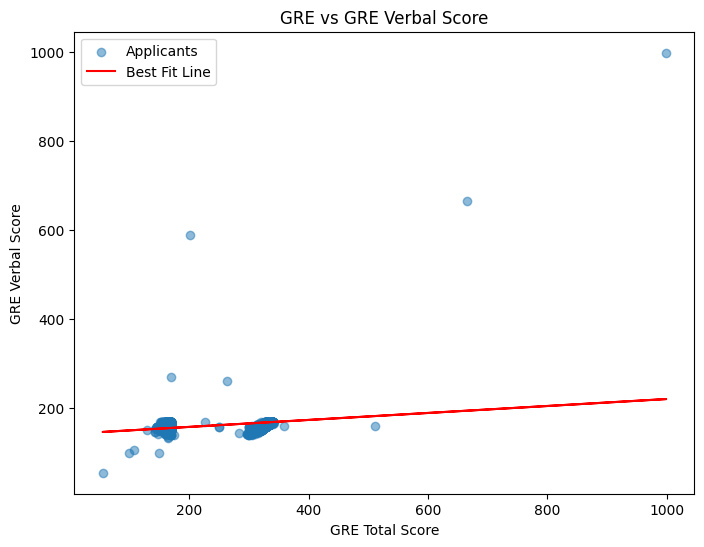

In [31]:
# Filter valid values
scatter_df = df[(df["gre_score"] > 0) & (df["gre_v_score"] > 0)]

x = scatter_df["gre_score"]
y = scatter_df["gre_v_score"]

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5, label="Applicants")

# Best fit line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red", label="Best Fit Line")

plt.title("GRE vs GRE Verbal Score")
plt.xlabel("GRE Total Score")
plt.ylabel("GRE Verbal Score")
plt.legend()

plt.savefig("GRE-vs-GRE-V.png", dpi=300)
plt.show()

### GPA vs GRE Score
Scatter plot comparing GPA values and GRE scores with a best-fit regression line.

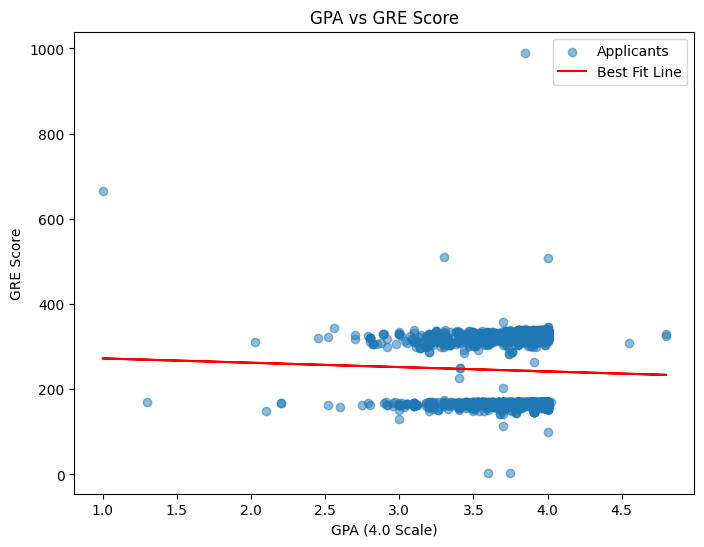

In [32]:
scatter_df = df[(df["gpa"] > 0) & (df["gre_score"] > 0)]

x = scatter_df["gpa"]
y = scatter_df["gre_score"]

plt.figure(figsize=(8,6))
plt.scatter(x, y, alpha=0.5, label="Applicants")

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color="red", label="Best Fit Line")

plt.title("GPA vs GRE Score")
plt.xlabel("GPA (4.0 Scale)")
plt.ylabel("GRE Score")
plt.legend()

plt.savefig("GPA-vs-GRE.png", dpi=300)
plt.show()

### Degree vs US/International Status
Bar chart showing the number of applicants by degree type and nationality category.

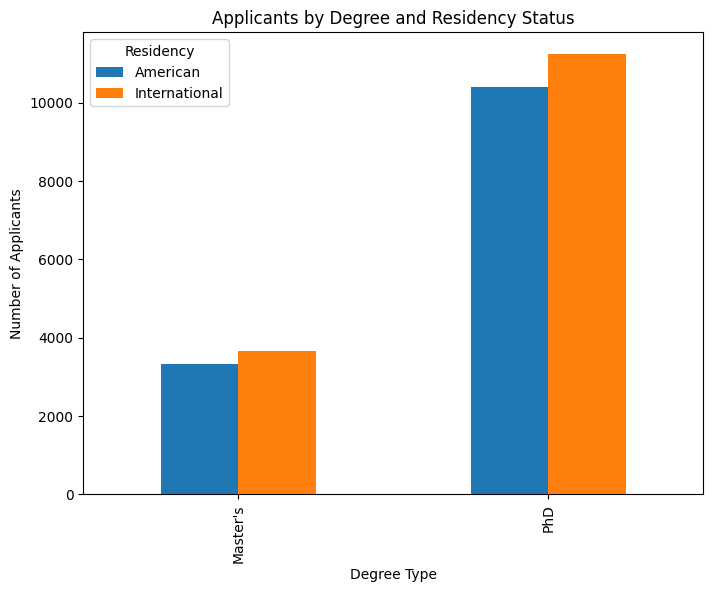

In [33]:
degree_table = pd.crosstab(df["degree"], df["international_american"])

degree_table.plot(kind="bar", figsize=(8,6))

plt.title("Applicants by Degree and Residency Status")
plt.xlabel("Degree Type")
plt.ylabel("Number of Applicants")
plt.legend(title="Residency")

plt.savefig("Degree-vs-International.png", dpi=300)
plt.show()

### Acceptances Over Time
Histogram showing the distribution of acceptance decisions by decision date.

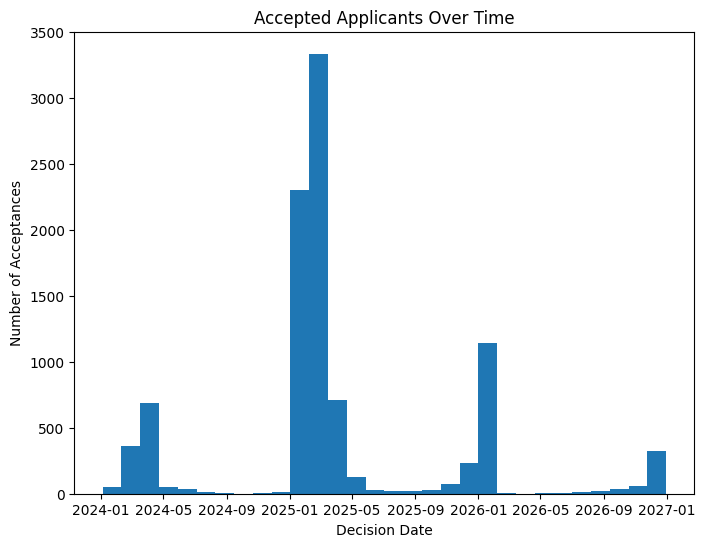

In [34]:
accept_df = df[df["outcome"] == "Accepted"].copy()
accept_df = accept_df.dropna(subset=["decision_date"])

plt.figure(figsize=(8,6))

plt.hist(accept_df["decision_date"], bins=30)

plt.title("Accepted Applicants Over Time")
plt.xlabel("Decision Date")
plt.ylabel("Number of Acceptances")

plt.savefig("Acceptances-over-Time.png", dpi=300)
plt.show()

### GPA Distribution by Outcome
Boxplot comparing GPA distributions for each application outcome.

<Figure size 800x600 with 0 Axes>

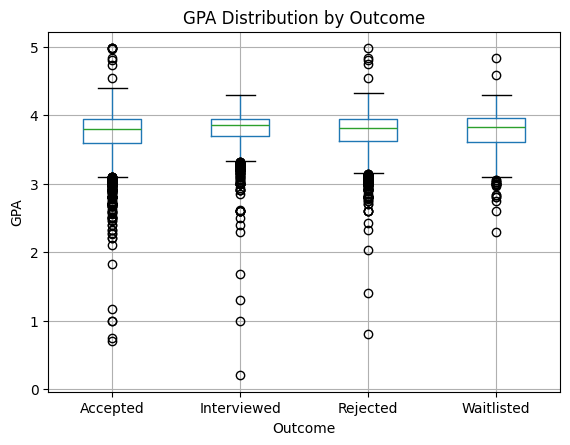

In [35]:
plt.figure(figsize=(8,6))

df.boxplot(column="gpa", by="outcome")

plt.title("GPA Distribution by Outcome")
plt.suptitle("")
plt.xlabel("Outcome")
plt.ylabel("GPA")

plt.savefig("GPA-by-Outcome.png", dpi=300)
plt.show()

### Numeric Correlation Heatmap
Heatmap showing correlations among GPA and GRE-related numeric variables.

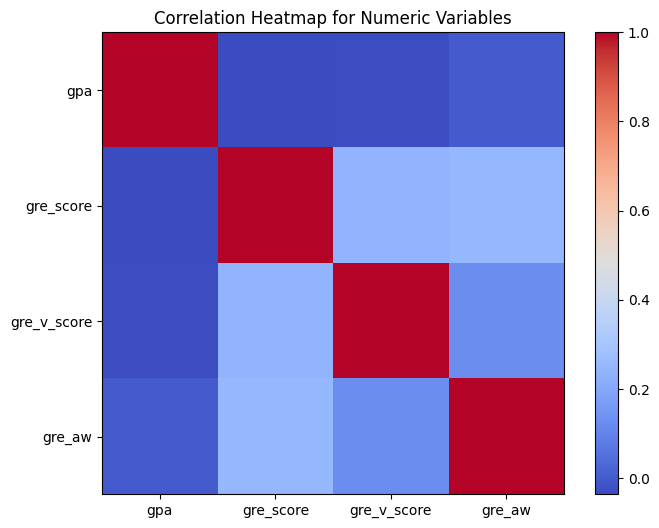

In [36]:
corr_cols = ["gpa", "gre_score", "gre_v_score", "gre_aw"]

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols)
plt.yticks(range(len(corr_cols)), corr_cols)

plt.title("Correlation Heatmap for Numeric Variables")

plt.savefig("Numeric-Correlation-Heatmap.png", dpi=300)
plt.show()

### Compute Key Admission Statistics

This section calculates two summary statistics used in the analytical report:

- The **average GRE score** of applicants who were **accepted into PhD programs**.
- The **average GPA** of applicants who were **accepted into Master's programs**.

The calculations filter the cleaned dataset to include only rows where the degree type and outcome match the criteria. The mean values are then computed using Pandas to summarize the academic profiles of successful applicants.

In [37]:
phd_gre_avg = df[(df["degree"] == "PhD") & (df["outcome"] == "Accepted")]["gre_score"].mean()

masters_gpa_avg = df[(df["degree"] == "Master's") & (df["outcome"] == "Accepted")]["gpa"].mean()

print("Average GRE for accepted PhD:", phd_gre_avg)
print("Average GPA for accepted Master's:", masters_gpa_avg)

Average GRE for accepted PhD: 251.42127659574467
Average GPA for accepted Master's: 3.690451063829787


## 9. Save the Cleaned Dataset and Upload to S3

After completing the cleaning and analysis process, the cleaned dataset is exported to a JSON file and uploaded back to the S3 bucket. This allows the processed dataset to be reused for future analysis or downstream workflows.

In [38]:
cleaned_path = "cleaned_gradcafe.json"

df.to_json(cleaned_path, orient="records", indent=2)

print("Cleaned dataset saved locally as:", cleaned_path)

Cleaned dataset saved locally as: cleaned_gradcafe.json


In [39]:
# Create S3 client
s3 = boto3.client("s3")

bucket_name = "grad-cafe-ic"
s3_key = "cleaned_gradcafe.json"

# Upload file
s3.upload_file(cleaned_path, bucket_name, s3_key)

print(f"Upload successful! {cleaned_path} uploaded to s3://{bucket_name}/{s3_key}")

Upload successful! cleaned_gradcafe.json uploaded to s3://grad-cafe-ic/cleaned_gradcafe.json
